<a href="https://colab.research.google.com/github/akosinyll1404/Machine-Learning-Projects/blob/main/MidTerm_Skill_Exam_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MIDTERM SKILL EXAM

Submittted by: Jann Moises Nyll B. De los Reyes

# Import necessary libraries for the following ML Algorithm

In [ ]:
#import necessary libraries for Random Forest, Decision Trees, Bagging, Stacked Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import StackingClassifier

In [ ]:
#import necessary libraries for training and testing of the model
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
#import necessary libraries for evaluation of the performance of the model Accuracy, Precision and Recall,ROC AUC,Confusion Matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, classification_report,roc_curve

In [ ]:
#import necessary libaries for
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


%matplotlib inline

# Load the dataset

In [ ]:
#upload the fetal health dataset
import pandas as pd
df = pd.read_csv('/content/fetal_health.csv')

In [ ]:
#display the first 10 of the data
df.head(10)

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.000,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.000,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.000,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.000,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.000,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0
5,134.0,0.001,0.0,0.010,0.009,0.0,0.002,26.0,5.9,0.0,...,50.0,200.0,5.0,3.0,76.0,107.0,107.0,170.0,0.0,3.0
6,134.0,0.001,0.0,0.013,0.008,0.0,0.003,29.0,6.3,0.0,...,50.0,200.0,6.0,3.0,71.0,107.0,106.0,215.0,0.0,3.0
7,122.0,0.000,0.0,0.000,0.000,0.0,0.000,83.0,0.5,6.0,...,62.0,130.0,0.0,0.0,122.0,122.0,123.0,3.0,1.0,3.0
8,122.0,0.000,0.0,0.002,0.000,0.0,0.000,84.0,0.5,5.0,...,62.0,130.0,0.0,0.0,122.0,122.0,123.0,3.0,1.0,3.0
9,122.0,0.000,0.0,0.003,0.000,0.0,0.000,86.0,0.3,6.0,...,62.0,130.0,1.0,0.0,122.0,122.0,123.0,1.0,1.0,3.0


In [ ]:
#Check the datatypes
df.dtypes

,0
baseline value,float64
accelerations,float64
fetal_movement,float64
uterine_contractions,float64
light_decelerations,float64
severe_decelerations,float64
prolongued_decelerations,float64
abnormal_short_term_variability,float64
mean_value_of_short_term_variability,float64
percentage_of_time_with_abnormal_long_term_variability,float64


In [ ]:
df['fetal_health'].value_counts()

,count
fetal_health,
1.0,1655
2.0,295
3.0,176


In [ ]:
#check for the missing data
df.isnull().sum()

,0
baseline value,0
accelerations,0
fetal_movement,0
uterine_contractions,0
light_decelerations,0
severe_decelerations,0
prolongued_decelerations,0
abnormal_short_term_variability,0
mean_value_of_short_term_variability,0
percentage_of_time_with_abnormal_long_term_variability,0


In [ ]:
#check for the size of the data
df.shape

(2126, 22)

# Train-test split

In [ ]:
#Make a train-test split for the model
X = df.drop('fetal_health', axis=1)
y = df['fetal_health']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
#check train and test  size
print(X_train.shape)
print(X_test.shape)

(1700, 21)
(426, 21)


#ML Algorithms Training
# Random Forest Model

In [ ]:
RF = RandomForestClassifier(oob_score=True,
                            random_state=42,
                            warm_start=True,
                            n_jobs=-1)

oob_list = list()

# Iterate through all of the possibilities for
# number of trees
for n_trees in [15, 20, 30, 40, 50, 100, 150, 200, 300, 400,600,800]:

    # Use this to set the number of trees
    RF.set_params(n_estimators=n_trees)

    # Fit the model
    RF.fit(X_train, y_train)

    # Get the oob error
    oob_error = 1 - RF.oob_score_

    # Store it
    oob_list.append(pd.Series({'n_trees': n_trees, 'oob': oob_error}))

rf_oob_df = pd.concat(oob_list, axis=1).T.set_index('n_trees')

rf_oob_df

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:615: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:615: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


,oob
n_trees,
15.0,0.067647
20.0,0.068824
30.0,0.068235
40.0,0.067059
50.0,0.065294
100.0,0.060000
150.0,0.059412
200.0,0.057647
300.0,0.057647


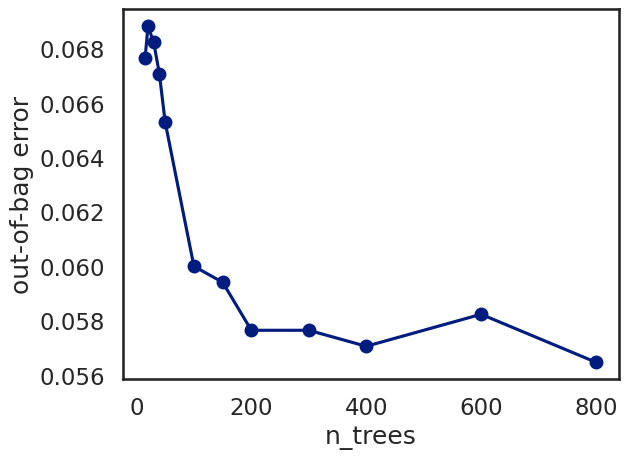

In [ ]:
sns.set_context('talk')
sns.set_palette('dark')
sns.set_style('white')

ax = rf_oob_df.plot(legend=False, marker='o')
ax.set(ylabel='out-of-bag error');

# Hypertuning the Parameters for the Random Forest using Grid Search CV and RandomSearch

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

In [ ]:
#Setting up GridSearch parameters for Random Forest
param_grid = {
    'n_estimators': [200, 400,800],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth' : [10,20,30],
    'criterion' :['gini', 'entropy']
}
param_dist = {
    'n_estimators': [int(x) for x in np.linspace(start = 200, stop = 2000, num = 10)],
    'max_features': ['auto', 'sqrt'],
    'max_depth': [int(x) for x in np.linspace(10, 110, num = 11)],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}


In [ ]:
#Perform GridSearchCV for RandomForest
grid_search = GridSearchCV(estimator=RF, param_grid=param_grid, cv= 5)
grid_search.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
90 fits failed out of a total of 270.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
90 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/utils/

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(n_estimators=800, n_jobs=-1,
                                              oob_score=True, random_state=42,
                                              warm_start=True),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [10, 20, 30],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'n_estimators': [200, 400, 800]})

In [ ]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': 20,
 'max_features': 'sqrt',
 'n_estimators': 400}

In [ ]:
grid_search.best_score_

0.9394117647058824

In [ ]:
# Evaluate performance
def evaluate_model(search, X_train, X_test, y_train, y_test, name):
    print(f"Results for {name} Search")
    # Training set performance
    y_train_pred = search.predict(X_train)
    print(f"Training Accuracy: {search.score(X_train, y_train):.4f}")
    print("Training Classification Report:")
    print(classification_report(y_train, y_train_pred))

    # Testing set performance
    y_test_pred = search.predict(X_test)
    print(f"Testing Accuracy: {search.score(X_test, y_test):.4f}")
    print("Testing Classification Report:")
    print(classification_report(y_test, y_test_pred))

    # Confusion matrix for test set
    print(f"Confusion Matrix (Test Set) for {name}:")
    print(confusion_matrix(y_test, y_test_pred))

    #ROC AUC Score
    # Get predicted probabilities for each class
    y_probs = search.predict_proba(X_test)  # Or random_search.predict_proba(X_test)

    # Calculate and print overall ROC AUC (using 'ovr' or 'ovo')
    roc_auc_ovr = roc_auc_score(y_test, y_probs, multi_class='ovr')
    print(f"Overall ROC AUC Score (OvR): {roc_auc_ovr:.4f}")

    roc_auc_ovo = roc_auc_score(y_test, y_probs, multi_class='ovo')
    print(f"Overall ROC AUC Score (OvO): {roc_auc_ovo:.4f}")

    # Plot ROC curves for each class separately
    classes = np.unique(y_test)
    plt.figure(figsize=(8, 6))
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_test, y_probs[:, i], pos_label=classes[i])
        roc_auc_class = roc_auc_score(y_test == classes[i], y_probs[:, i])  # AUC for this class
        plt.plot(fpr, tpr, label=f'Class {classes[i]} (AUC = {roc_auc_class:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves for Individual Classes')
    plt.legend(loc='lower right')
    plt.show()


Results for Grid Search Search
Training Accuracy: 1.0000
Training Classification Report:
              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00      1322
         2.0       1.00      1.00      1.00       231
         3.0       1.00      1.00      1.00       147

    accuracy                           1.00      1700
   macro avg       1.00      1.00      1.00      1700
weighted avg       1.00      1.00      1.00      1700

Testing Accuracy: 0.9296
Testing Classification Report:
              precision    recall  f1-score   support

         1.0       0.96      0.96      0.96       333
         2.0       0.81      0.78      0.79        64
         3.0       0.90      0.90      0.90        29

    accuracy                           0.93       426
   macro avg       0.89      0.88      0.88       426
weighted avg       0.93      0.93      0.93       426

Confusion Matrix (Test Set) for Grid Search:
[[320  10   3]
 [ 14  50   0]
 [  1   2  26]]
Ov

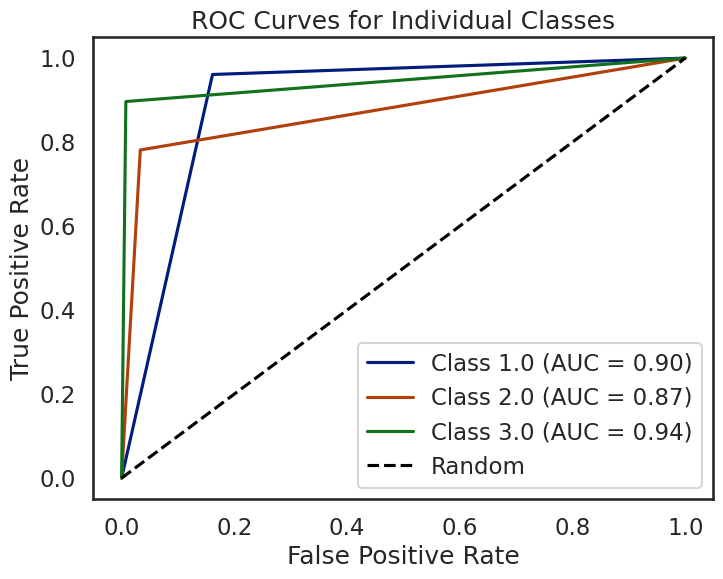

In [ ]:
evaluate_model(grid_search, X_train, X_test, y_train, y_test, "Grid Search")

**Interpretation:**

<font color = green> The hypertuned model got a 1.00 accuracy score in both training. Upon testing, the grid_search model got a 0.9460 in testing and 0.9507 for random_search. This suggest that our model is overfitting. On the 3 labels the overall ROC score  for the both hypertuned parameters are mostly to 0.98.

# Decision Trees Model

In [ ]:
#building a decision Trees model
dtree = DecisionTreeClassifier()
dtree.fit(X_train,y_train)

DecisionTreeClassifier()

In [ ]:
#determine the number of nodes and max depth
dtree.tree_.node_count, dtree.tree_.max_depth

(217, 13)

In [ ]:
tree_para = {'criterion':['gini','entropy'],'max_depth':[1,10,80,100,90,150,200]}
clf = GridSearchCV(DecisionTreeClassifier, tree_para, cv=5)

In [ ]:
#Perform GridSearchCV for DEcision Tree
grid_search = GridSearchCV(estimator=dtree, param_grid=tree_para, cv= 5)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [1, 10, 80, 100, 90, 150, 200]})

In [ ]:
grid_search.best_params_

{'criterion': 'entropy', 'max_depth': 100}

In [ ]:
grid_search.best_score_

0.9241176470588235

Results for Decision Tree Search
Training Accuracy: 1.0000
Training Classification Report:
              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00      1322
         2.0       1.00      1.00      1.00       231
         3.0       1.00      1.00      1.00       147

    accuracy                           1.00      1700
   macro avg       1.00      1.00      1.00      1700
weighted avg       1.00      1.00      1.00      1700

Testing Accuracy: 0.9249
Testing Classification Report:
              precision    recall  f1-score   support

         1.0       0.95      0.95      0.95       333
         2.0       0.77      0.78      0.78        64
         3.0       0.93      0.90      0.91        29

    accuracy                           0.92       426
   macro avg       0.88      0.88      0.88       426
weighted avg       0.93      0.92      0.93       426

Confusion Matrix (Test Set) for Decision Tree:
[[318  13   2]
 [ 14  50   0]
 [  1   2  26]

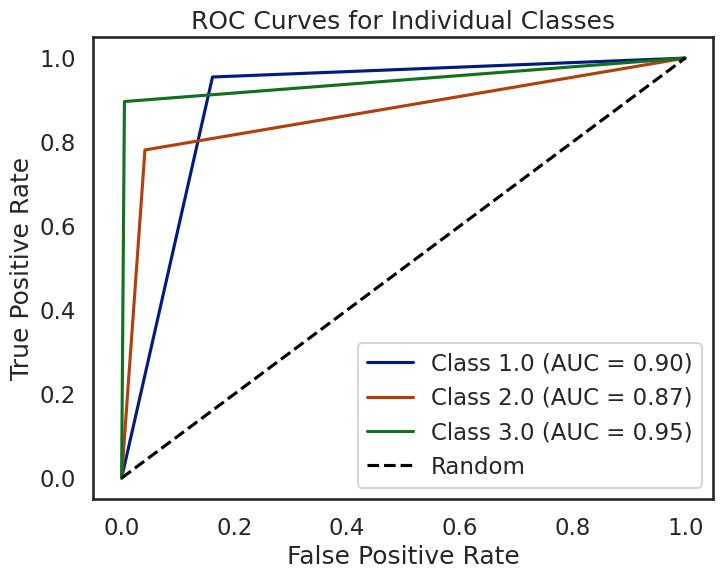

In [ ]:
evaluate_model(grid_search, X_train, X_test, y_train, y_test, "Decision Tree")

Interpretation:

<font color= green>In using the Decision Tree model  with  a hypertuned parameter using Grid search gave us a accuracy score on testing 0.9249 while having a 1.0  on training .This suggest  that our model may overfit  when testing to the other data. Our AUC Score for the 3 class are about 90% with class 2 having an AUC score of  0.87 which is the lowest compare to the class 1 with 0.9 and class 3 with 0.95 AUC score.

#Bagging Model

In [ ]:
#build a baggin model
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bagging = BaggingClassifier(
    DecisionTreeClassifier(),
    n_estimators=100,  # Number of base estimators (Decision Trees)
    random_state=42     # For reproducibility
)

In [ ]:
bagging.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100,
                  random_state=42)

In [ ]:
param_grid = {
    'n_estimators': [100, 200],  # Number of base estimators
    'max_samples': [0.5, 0.7, 1.0],  # Proportion of samples to draw
    'max_features': [0.5, 0.7, 1.0],  # Proportion of features to draw
}

In [ ]:
grid_search = GridSearchCV(
    estimator=bagging,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

# Print the best parameters and score
print(grid_search.best_params_)
print(grid_search.best_score_)

{'max_features': 0.7, 'max_samples': 1.0, 'n_estimators': 100}
0.9400000000000001


Results for Bagging Tree Search
Training Accuracy: 1.0000
Training Classification Report:
              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00      1322
         2.0       1.00      1.00      1.00       231
         3.0       1.00      1.00      1.00       147

    accuracy                           1.00      1700
   macro avg       1.00      1.00      1.00      1700
weighted avg       1.00      1.00      1.00      1700

Testing Accuracy: 0.9484
Testing Classification Report:
              precision    recall  f1-score   support

         1.0       0.96      0.98      0.97       333
         2.0       0.88      0.80      0.84        64
         3.0       0.93      0.93      0.93        29

    accuracy                           0.95       426
   macro avg       0.92      0.90      0.91       426
weighted avg       0.95      0.95      0.95       426

Confusion Matrix (Test Set) for Bagging Tree:
[[326   6   1]
 [ 12  51   1]
 [  1   1  27]]


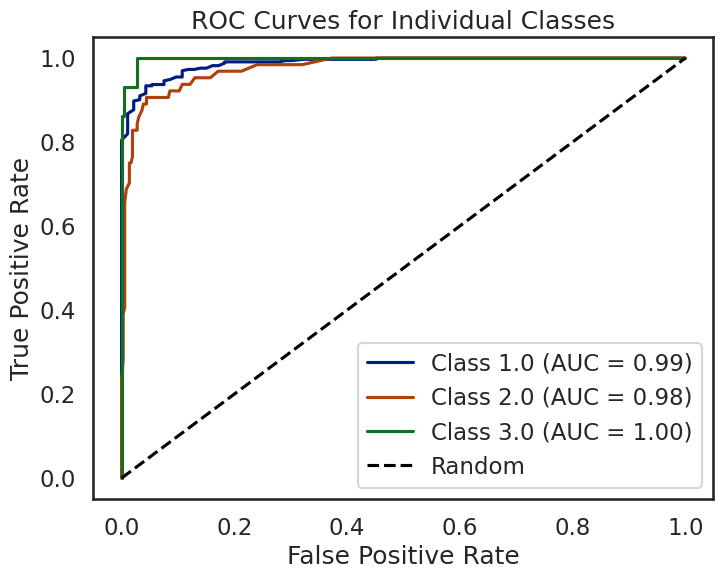

In [ ]:
evaluate_model(grid_search, X_train, X_test, y_train, y_test, "Bagging Tree")

#Interpretation:

Using Bagging  we got  a testing accuracy of 0.9484. Our model may be overfit because our data is skewed. We got auc roc score of around 0.98 in each class  we got around 0.99,0.98,1 for class 1,2,3 respectively.

#Stacking Model

In [ ]:
base

In [ ]:
from sklearn.linear_model import LogisticRegressionCV

# L2 regularized logistic regression
LR_L2 = LogisticRegressionCV(Cs=5, cv=4, penalty='l2').fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

## Overall Analysis and Interpretation to the Result of each data.

We manage to get the result of  the  Random forest, Decision Tree and  Bagging on time. Overall the Bagging gives the best result with accuracy of  94% and  AUC ROC score of  0.9484 followed by the Random forest and Decision Tree respectively.